In [ ]:
# Currently, SmartCart uses generic marketing and engagement strategies for all customers, without clearly understanding different customer behaviour patterns.
# This results in inefficient marketing, missed opportunities to retain high-value customers, and delayed identification of churn-prone users.
# To solve this, SmartCart aims to build an intelligent customer segmentation system using unsupervised machine learning. The system will analyse historical customer transaction data and group customers into meaningful clusters based on purchasing behaviour, engagement levels, and loyalty indicators.
# You are hired as an Al/ML Engineer to develop this system using clustering algorithms to discover hidden patterns in customer behaviour and support data-driven decision-making for personalised marketing and customer retention.

In [46]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [47]:
data=pd.read_csv("smartcart_customers.csv")
data.tail(20)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
2220,6261,1979,Graduation,Married,58025.0,0,1,26-11-2013,81,270,...,11,48,22,3,3,2,10,4,0,0
2221,7366,1982,Master,Single,75777.0,0,0,04-07-2013,12,712,...,69,13,80,1,3,6,11,1,0,1
2222,10659,1979,2n Cycle,Together,7500.0,1,0,07-05-2013,7,2,...,3,8,21,4,3,2,2,7,0,0
2223,1448,1963,Master,Married,33562.0,1,2,25-06-2014,33,21,...,0,3,3,3,2,0,4,4,0,0
2224,4286,1970,PhD,Single,57642.0,0,1,09-01-2014,24,580,...,8,0,27,3,7,6,6,4,0,0
2225,4749,1968,Graduation,Together,58554.0,1,1,26-09-2012,55,368,...,38,0,88,6,8,2,6,7,0,0
2226,4478,1979,Graduation,Married,63777.0,1,1,24-03-2013,87,457,...,15,17,53,8,11,1,6,8,0,0
2227,4201,1962,Graduation,Single,57967.0,0,1,03-03-2013,39,229,...,4,0,91,5,4,2,8,5,0,0
2228,8720,1978,2n Cycle,Together,NaN,0,0,12-08-2012,53,32,...,12,4,22,0,0,0,1,0,0,0
2229,10084,1972,Graduation,Married,24434.0,2,0,18-05-2014,9,3,...,20,0,17,2,2,1,2,7,0,0


In [48]:
#fill missing values
data.info()
data.isna().sum() #income has null values
data["Income"] = data["Income"].fillna(
    data["Income"].median())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [49]:
#feature engineering

#year of birth col to be converted to age
data["Age"]=2026-data["Year_Birth"]

#Get the customer tenire days onSmartcart
data["Dt_Customer"]=pd.to_datetime(data["Dt_Customer"],dayfirst=True)
reference_date=data["Dt_Customer"].max()
data["Customer_Tenure_days"]=(reference_date-data["Dt_Customer"]).dt.days

#Spending is clubbed into one feature
data["Spending"]=data["MntWines"]+data["MntFruits"]+data["MntMeatProducts"]+data["MntFishProducts"]+data["MntSweetProducts"]+data["MntGoldProds"]

data["Total_Children"]=data["Kidhome"]+data["Teenhome"]

#Handle education
data["Education"]= data["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate",
    "PhD":"Postgraduate"
})

#Handle Marital Status
data["Living_With"]=data["Marital_Status"].replace({
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone",
    "Married":"Partner",
    "Together":"Partner"
})
data_cleaned=data.drop(columns=["Kidhome","Teenhome","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds","ID","Dt_Customer","Year_Birth","Marital_Status"],axis=1)

In [50]:
#Outliers
cols=["Income","Recency","Response","Age","Spending","Total_Children"]
import seaborn as sns
#sns.pairplot(data_cleaned[cols])

data_cleaned=data_cleaned[(data_cleaned["Age"]<90)]
data_cleaned=data_cleaned[data_cleaned["Income"]<600_000]

<Axes: >

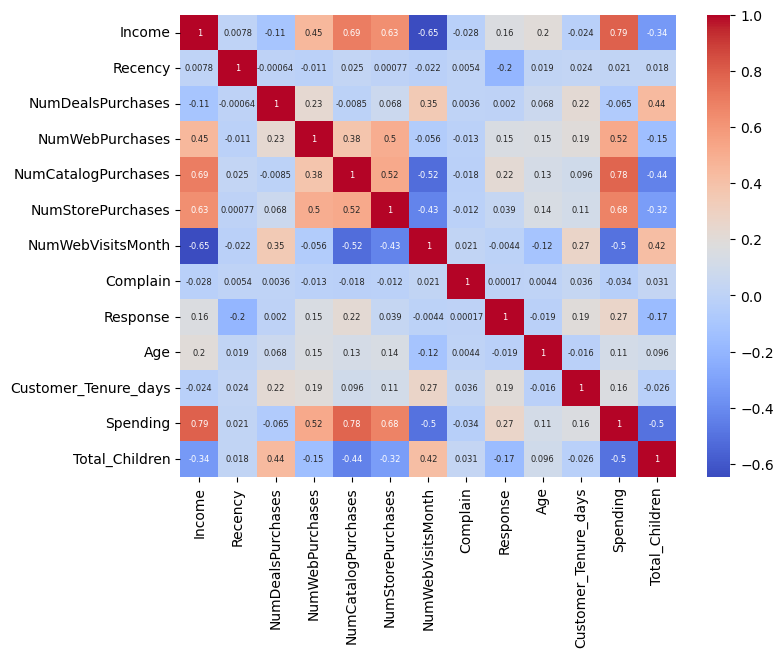

In [51]:
# heatmap of the features
corr=data_cleaned.corr(numeric_only=True)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,annot_kws={"size":6},cmap="coolwarm")

In [52]:
#Encoding
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
object_cols=["Education","Living_With"]
encoded = ohe.fit_transform(data_cleaned[object_cols])
encoded_df=pd.DataFrame(encoded.toarray(),columns=ohe.get_feature_names_out(object_cols),index=data_cleaned.index)
encoded_df.head()
data_cleaned = pd.concat(
    [data_cleaned.drop(columns=object_cols), encoded_df],
    axis=1
)

In [55]:
#scaling
X=data_cleaned
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

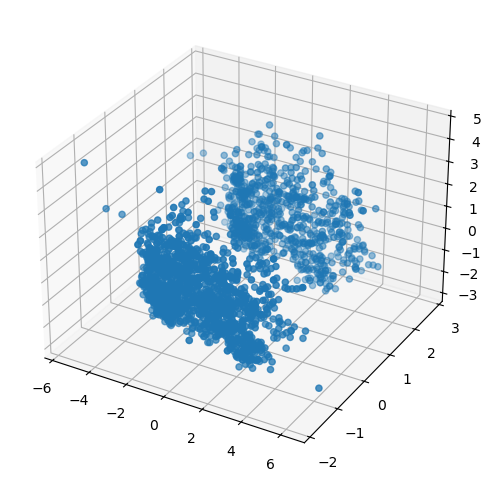

In [66]:
# Visualisze the data usinfg PCA
# 2d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca=PCA(n_components=3)

X_pca=pca.fit_transform(X_scaled)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
#plot
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

In [63]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

In [68]:
# CHOOSE K
## 1. Elbow method
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow
optimal_k

np.int64(4)

# Clustering

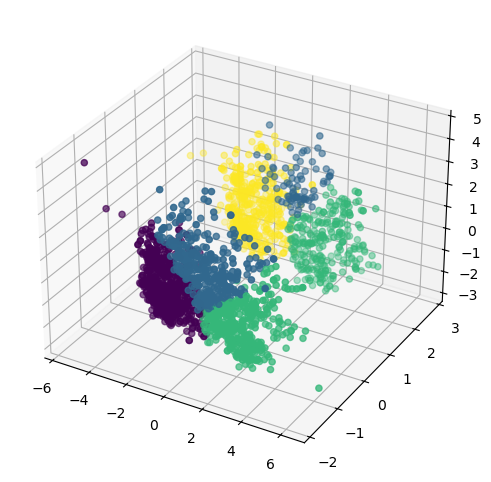

In [71]:
# Kmeans
kmeans=KMeans(n_clusters=4,random_state=42)
kmeans_labels=kmeans.fit_predict(X_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
#plot
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=kmeans_labels)

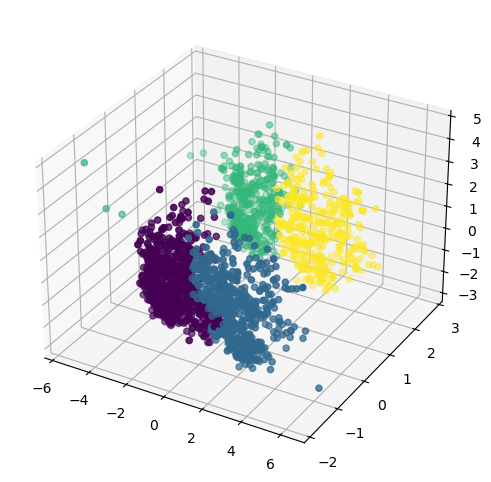

In [72]:
# Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
agg=AgglomerativeClustering(n_clusters=4,linkage="ward")
agg_labels=agg.fit_predict(X_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
#plot
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=agg_labels)